In [4]:
import pandas as pd

from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv("/content/drive/MyDrive/Superstore.csv", encoding='latin1')

df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [5]:
# Understand the data

print("Shape:", df.shape)
df.info()
df.describe()
df.isnull().sum()


Shape: (9994, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   flo

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


In [7]:
# Data Cleaning

# Convert date columns
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

# Create new useful columns
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month

In [8]:
# Core Business KPIs

print("Total Sales:", df['Sales'].sum())
print("Total Profit:", df['Profit'].sum())
print("Total Quantity:", df['Quantity'].sum())

Total Sales: 2297200.8603000003
Total Profit: 286397.0217
Total Quantity: 37873


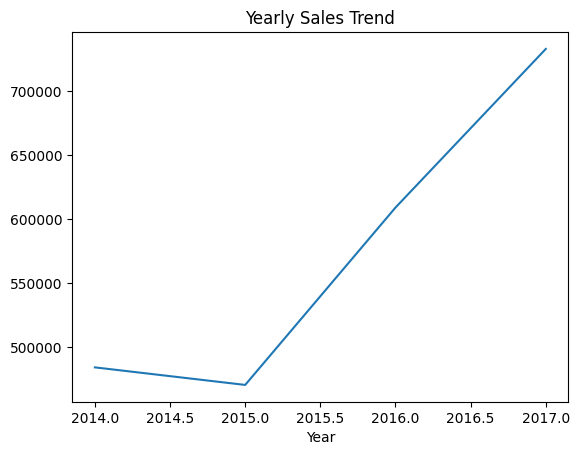

In [9]:
# Sales Trend Over Time
import matplotlib.pyplot as plt

yearly_sales = df.groupby('Year')['Sales'].sum()

yearly_sales.plot()
plt.title("Yearly Sales Trend")
plt.show()

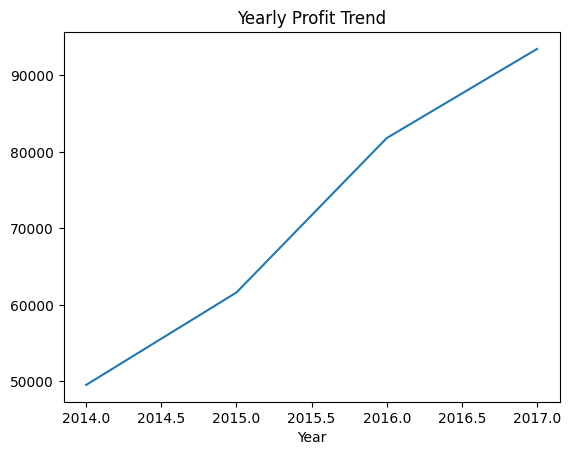

In [10]:
# Profit Trend Over Time
yearly_profit = df.groupby('Year')['Profit'].sum()

yearly_profit.plot()
plt.title("Yearly Profit Trend")
plt.show()

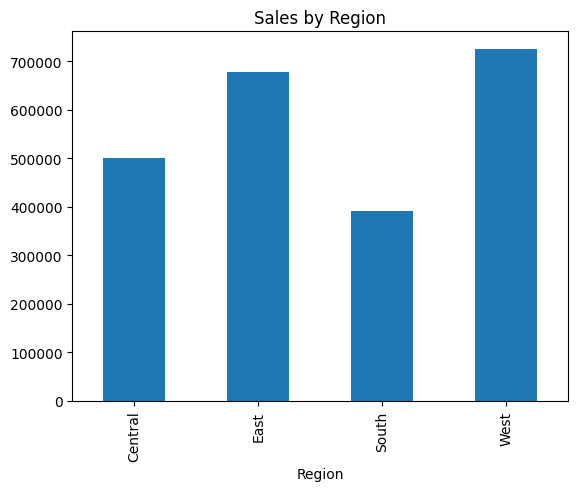

In [11]:
# Sales by Region
df.groupby('Region')['Sales'].sum().plot(kind='bar')
plt.title("Sales by Region")
plt.show()

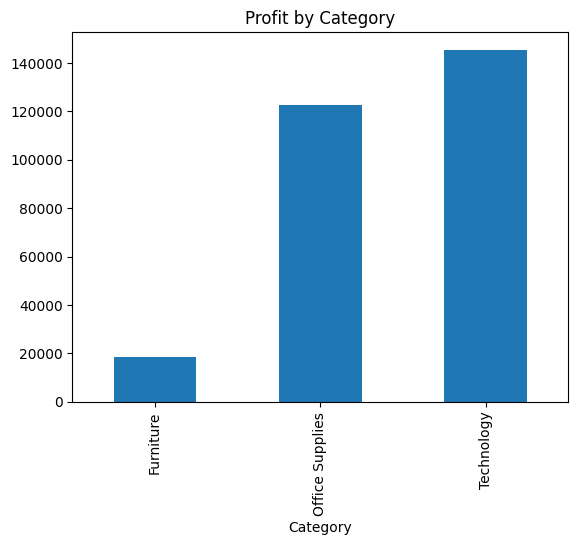

In [12]:
# Profit by Category
df.groupby('Category')['Profit'].sum().plot(kind='bar')
plt.title("Profit by Category")
plt.show()

In [14]:
# Top 10 Products
top_products = df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(10)

print(top_products)

Product Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
GBC Ibimaster 500 Manual ProClick Binding System                               19024.500
Hewlett Packard LaserJet 3310 Copier                                           18839.686
HP Designjet T520 Inkjet Large Format Printer - 24" Color                      18374.895
GBC DocuBind P400 Electric Binding System                                      17965.068
High Speed Automatic Electric Letter Opener                                    17030.312
Name: Sales, dtype: float64


In [15]:
# Loss-Making Products 🔥
loss_products = df[df['Profit'] < 0]

loss_products.groupby('Product Name')['Profit'].sum().sort_values().head(10)

,Profit
Product Name,
Cubify CubeX 3D Printer Double Head Print,-9239.9692
GBC DocuBind P400 Electric Binding System,-6859.3896
Lexmark MX611dhe Monochrome Laser Printer,-5269.9690
GBC Ibimaster 500 Manual ProClick Binding System,-5098.5660
GBC DocuBind TL300 Electric Binding System,-4162.0336
Cubify CubeX 3D Printer Triple Head Print,-3839.9904
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind,-3431.6730
Chromcraft Bull-Nose Wood Oval Conference Tables & Bases,-3107.5272
Ibico EPK-21 Electric Binding System,-2929.4845


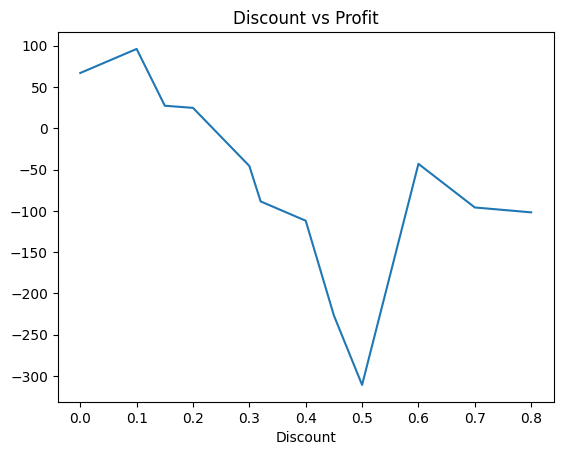

In [16]:
# Discount Impact
discount_profit = df.groupby('Discount')['Profit'].mean()

discount_profit.plot()
plt.title("Discount vs Profit")
plt.show()

In [17]:
# Top Customers
top_customers = df.groupby('Customer Name')['Sales'].sum().sort_values(ascending=False).head(10)

print(top_customers)

Customer Name
Sean Miller           25043.050
Tamara Chand          19052.218
Raymond Buch          15117.339
Tom Ashbrook          14595.620
Adrian Barton         14473.571
Ken Lonsdale          14175.229
Sanjit Chand          14142.334
Hunter Lopez          12873.298
Sanjit Engle          12209.438
Christopher Conant    12129.072
Name: Sales, dtype: float64


In [18]:
# Shipping Analysis
df['Delivery Time'] = (df['Ship Date'] - df['Order Date']).dt.days

df['Delivery Time'].describe()

,Delivery Time
count,9994.000000
mean,3.958175
std,1.747567
min,0.000000
25%,3.000000
50%,4.000000
75%,5.000000
max,7.000000
